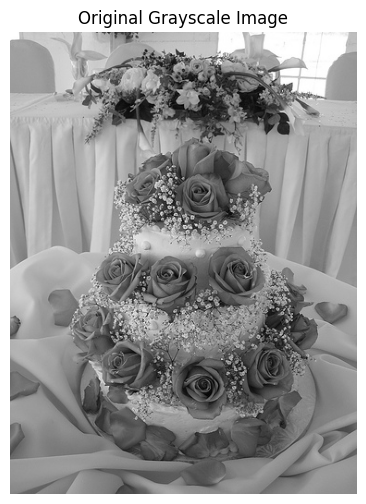

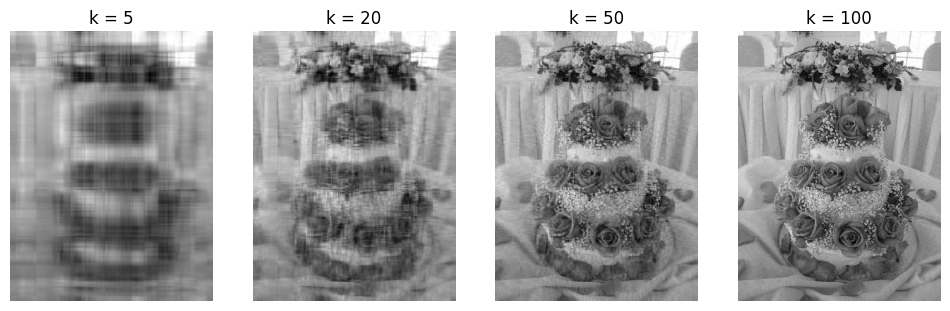

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2  # Ensure OpenCV is installed

# Load the image in grayscale
image_path = r"/content/sample_data/Image.png"  # Use 'r' to handle file path correctly
gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded correctly
if gray_image is None:
    print("Error: Image not found! Check the file path.")
else:
    # Display the original grayscale image
    plt.figure(figsize=(6, 6))
    plt.imshow(gray_image, cmap='gray')
    plt.title("Original Grayscale Image")
    plt.axis('off')
    plt.show()

    # Apply Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(gray_image, full_matrices=False)

    # Function to reconstruct image using top k singular values
    def reconstruct_image(k):
        """Reconstruct image using top k singular values."""
        reconstructed = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))
        return np.clip(reconstructed, 0, 255)  # Ensure pixel values are in range

    # Test different values of k and show images
    k_values = [5, 20, 50, 100]  # Adjust k values as needed
    fig, axes = plt.subplots(1, len(k_values), figsize=(12, 6))

    for i, k in enumerate(k_values):
        reconstructed_img = reconstruct_image(k)
        axes[i].imshow(reconstructed_img, cmap='gray')
        axes[i].set_title(f"k = {k}")
        axes[i].axis('off')

    plt.show()